In [1]:
!pip install ultralytics easyocr pandas opencv-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 34.2 MB/s eta 0:00:00


In [2]:
import torch
print(torch.cuda.is_available())


True


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
%pip install -q -U gdown==5.2.0 supervision==0.24.0 ultralytics==8.3.12 lapx==0.5.11
import os
import subprocess
import warnings
from collections import defaultdict
from typing import Any

import cv2 as cv
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import supervision as sv
from IPython.display import Video
from numpy.typing import ArrayLike, NDArray
from scipy.signal import savgol_filter
from ultralytics import YOLO

TICKSIZE = 12
FONT_COLOR = "#4A4B52"
GRADIENT_COLOR = "#BAB8B8"
BACKGROUND_COLOR = "#FFFCFA"
# TEXT = r"\textrm{{{}}}"

MATPLOTLIB_THEME = {
    "axes.labelcolor": FONT_COLOR,
    "axes.labelsize": TICKSIZE,
    "axes.facecolor": BACKGROUND_COLOR,
    "axes.titlesize": 16,
    "axes.grid": False,
    "axes.spines.bottom": False,
    "axes.spines.left": False,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "xtick.labelsize": TICKSIZE,
    "xtick.color": FONT_COLOR,
    "ytick.labelsize": TICKSIZE,
    "ytick.color": FONT_COLOR,
    "figure.facecolor": BACKGROUND_COLOR,
    "figure.edgecolor": BACKGROUND_COLOR,
    "figure.titlesize": 16,
    "figure.dpi": 72,  # Locally Seaborn uses 72, meanwhile Kaggle 96.
    "text.color": FONT_COLOR,
    "font.size": TICKSIZE,
    # "text.usetex": True,
    "font.family": "Serif",
}
plt.rcParams.update(MATPLOTLIB_THEME)


SOURCE_VIDEO = "/content/drive/MyDrive/PROJECT VIDEOS /Relaxing highway traffic - Trim.mp4"

# verify whetger it can read the file
import os
print(f"Drive file detected successfully: {os.path.exists(SOURCE_VIDEO)}")



def imshow(img, figsize: tuple[int, int] = (11, 7)) -> None:
    plt.figure(figsize=figsize, tight_layout=True)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.0/871.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive file detected successfully: True


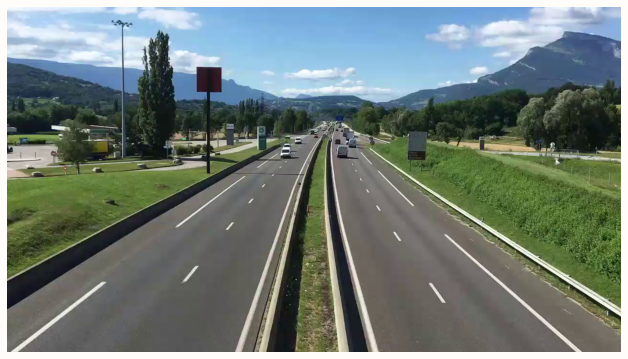

Success: Video frame read properly by OpenCV!


In [5]:
import cv2 as cv
import matplotlib.pyplot as plt

# open the video source
cap = cv.VideoCapture(SOURCE_VIDEO)
ret, frame = cap.read()

if ret:
    # convert to RGB
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)

    # DISPLAY THE FRAME
    plt.figure(figsize=(11, 7))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()
    print("Success: Video frame read properly by OpenCV!")
else:
    print("Error: Could not read the video file. Please check the path.")
cap.release()


 Perspective Transform


In [6]:
import cv2 as cv

cap = cv.VideoCapture(SOURCE_VIDEO)
fps = int(cap.get(cv.CAP_PROP_FPS)) # read video FPS
target_frame = 59 * fps # 59th frame reading (59 * 30 = 1770)

cap.set(cv.CAP_PROP_POS_FRAMES, target_frame)
ret, frame = cap.read()

if ret:
    # save the 59th frame
    cv.imwrite("frame_59.png", frame)
    print(f"✓ Success: Extracted frame at 59th second (Frame No: {target_frame})")
else:
    print("Error: Could not reach the 59th second. Please check the video length.")
cap.release()


✓ Success: Extracted frame at 59th second (Frame No: 1711)



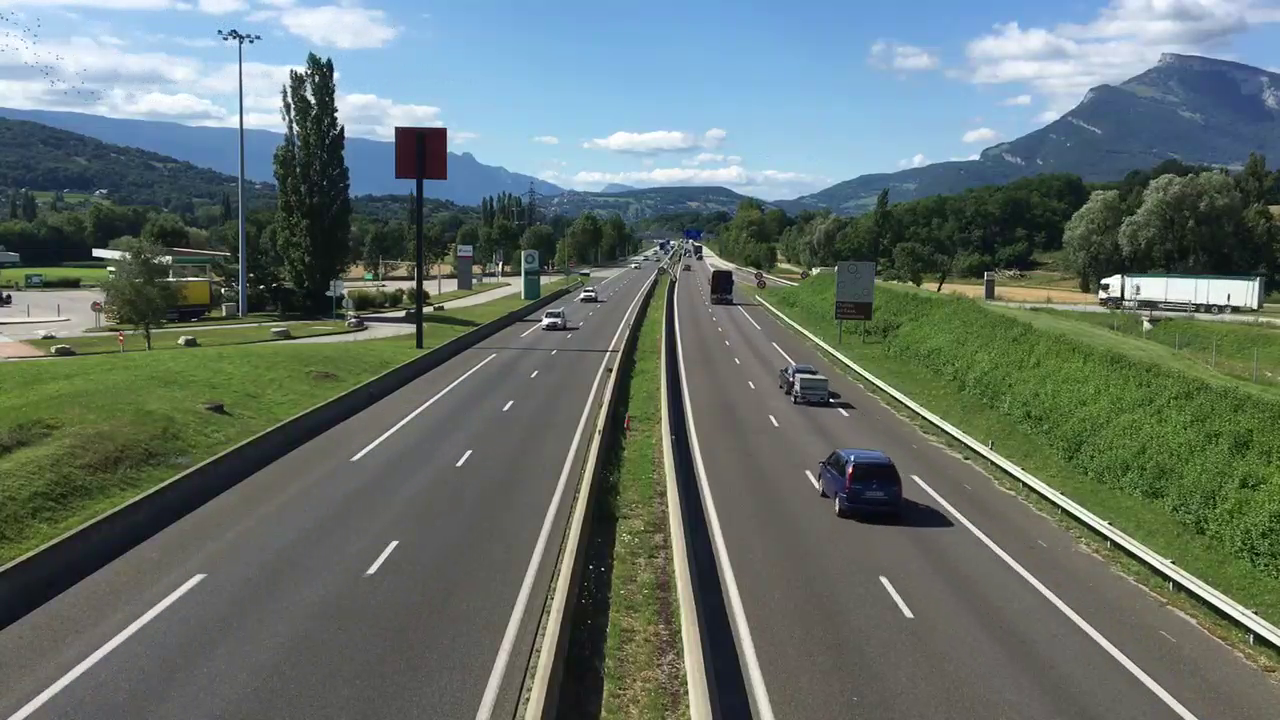

In [7]:
import cv2 as cv
import numpy as np
import base64
from IPython.display import display, HTML
import google.colab.output as colab_output

# 1. Load the picture
img = cv.imread("frame_59.png")
if img is None:
    raise FileNotFoundError("Error: 'frame_59.png' ফাইলটি খুঁজে পাওয়া যায়নি! দয়া করে ২২ সেকেন্ডের ফ্রেম এক্সট্রাকশন সেলটি আগে রান করুন।")

H, W, _ = img.shape

# 2. convert the pic in base64 to view in browser
_, encoded_img = cv.imencode('.png', img)
base64_img = base64.b64encode(encoded_img).decode('utf-8')

# 3. HTML and JAVASCRIPT ARCHITECTURE
html_code = f"""
<div style="font-family: Arial, sans-serif; margin-bottom: 15px; font-size: 14px; background-color: #f8f9fa; padding: 10px; border-left: 5px solid #007bff; border-radius: 4px;">
    <strong>🎯 নির্দেশনামতো রাস্তার ৪টি কোণায় ক্রমানুসারে মাউস দিয়ে ক্লিক করুন:</strong><br/>
    <span style="color:#dc3545; font-weight:bold;">১ম ক্লিক ➔ A (Top-Left)</span> |
    <span style="color:#28a745; font-weight:bold;">২য় ক্লিক ➔ B (Top-Right)</span> |
    <span style="color:#007bff; font-weight:bold;">৩য় ক্লিক ➔ C (Bottom-Right)</span> |
    <span style="color:#fd7e14; font-weight:bold;">৪র্থ ক্লিক ➔ D (Bottom-Left)</span>
</div>

<div style="position: relative; display: inline-block; border: 2px solid #ddd; border-radius: 4px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">
    <img id="traffic_img" src="data:image/png;base64,{base64_img}" style="max-width: 100%; height: auto; cursor: crosshair; display: block;"/>
    <canvas id="myCanvas" style="position: absolute; left: 0; top: 0; width: 100%; height: 100%; pointer-events: none;"></canvas>
</div>

<div id="output_box" style="margin-top: 15px; font-family: monospace; font-size: 14px; line-height: 1.6; color: #333; background: #fff; padding: 10px; border: 1px solid #eee; border-radius: 4px; min-height: 40px;"></div>

<script>
    var clicks = [];
    var labels = ["A", "B", "C", "D"];
    var colors = ["#dc3545", "#28a745", "#007bff", "#fd7e14"];
    var img = document.getElementById("traffic_img");
    var canvas = document.getElementById("myCanvas");
    var ctx = canvas.getContext("2d");

    img.onload = function() {{
        canvas.width = img.naturalWidth;
        canvas.height = img.naturalHeight;
    }};

    img.onclick = function(e) {{
        if (clicks.length >= 4) return;

        // ছবির রিয়েল পিক্সেল রেজোলিউশন অনুযায়ী নিখুঁত অনুপাত বের করা
        var rect = img.getBoundingClientRect();
        var scaleX = img.naturalWidth / rect.width;
        var scaleY = img.naturalHeight / rect.height;

        var x = Math.round((e.clientX - rect.left) * scaleX);
        var y = Math.round((e.clientY - rect.top) * scaleY);

        var current_label = labels[clicks.length];
        var current_color = colors[clicks.length];

        clicks.push({{x: x, y: y, label: current_label}});

        // ক্যানভাসের ওপর রঙিন ডট এবং লেবেল ড্র করা
        ctx.fillStyle = current_color;
        ctx.strokeStyle = "#fff";
        ctx.lineWidth = 3;
        ctx.beginPath();
        ctx.arc(x, y, 10, 0, 2 * Math.PI);
        ctx.fill();
        ctx.stroke();

        ctx.fillStyle = current_color;
        ctx.font = "bold 26px Arial";
        ctx.fillText(current_label, x + 15, y - 15);

        // লাইভ টেক্সট আউটপুট আপডেট
        var out = document.getElementById("output_box");
        out.innerHTML += "<span style='color:" + current_color + ";'>📍 Point " + current_label + "</span> ➔ <strong>X:</strong> " + x + ", <strong>Y:</strong> " + y + "<br/>";

        // ৪টি ক্লিক শেষ হলে পাইথনের মেইন রানটাইমে ডেটা ব্যাকআপ পাঠানো
        if (clicks.length === 4) {{
            google.colab.kernel.invokeFunction('notebook.save_coordinates', [clicks], {{}});
            out.innerHTML += "<br/><span style='color:#28a745; font-weight:bold;'>✓ ৪টি পয়েন্ট সফলভাবে পাইথন মেমরিতে সেভ হয়েছে! এবার নিচের সেলটি রান করুন।</span>";
        }}
    }};
</script>
"""

# ৪4. data receive in python from javascript
final_coords = []
def save_coordinates(coords):
    global final_coords
    final_coords = coords

colab_output.register_callback('notebook.save_coordinates', save_coordinates)

# render to screen
display(HTML(html_code))


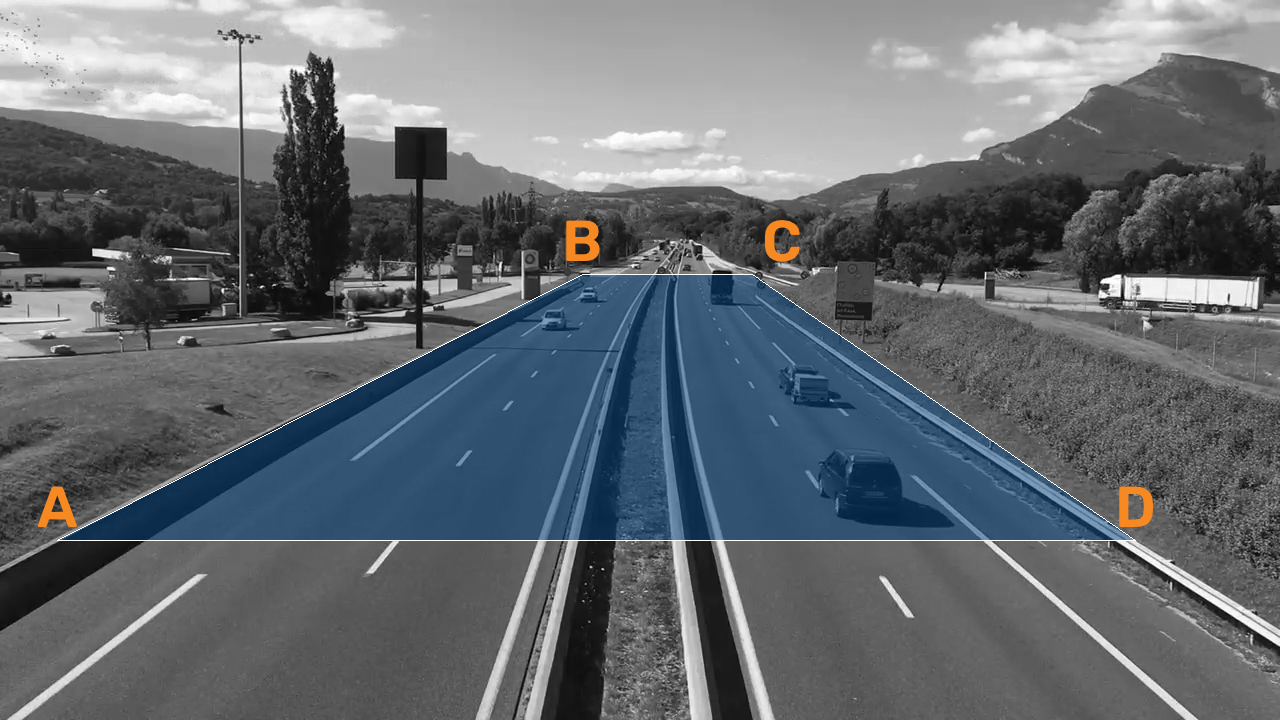

In [8]:
import cv2 as cv
import numpy as np
import supervision as sv
from google.colab.patches import cv2_imshow

cap = cv.VideoCapture(SOURCE_VIDEO)
fps = int(cap.get(cv.CAP_PROP_FPS))

# 1. read the new 59th sec frame
cap.set(cv.CAP_PROP_POS_FRAMES, 59 * fps)
ret, img = cap.read()
cap.release()

# 2. Black and white effect
img = cv.cvtColor(cv.cvtColor(img, cv.COLOR_BGR2GRAY), cv.COLOR_GRAY2BGR)

color1 = sv.Color.from_hex("#004080")
color2 = sv.Color.from_hex("#f78923")

#  (A -> B -> C -> D in serial)
X_A, Y_A = 57, 540    # Point A
X_B, Y_B = 582, 274   # Point B
X_C, Y_C = 752, 274   # Point C
X_D, Y_D = 1135, 540    # Point D

# make arrow in geometrical order
poly = np.array(((X_A, Y_A), (X_B, Y_B), (X_C, Y_C), (X_D, Y_D)))

# make up the ROI
img = sv.draw_filled_polygon(img, poly, color1, 0.5)
img = sv.draw_polygon(img, poly, sv.Color.WHITE, 1)

# positioning the coordinates(-40 pixel up)
img = sv.draw_text(img, "A", sv.Point(X_A, Y_A - 40), color2, 2, 6)
img = sv.draw_text(img, "B", sv.Point(X_B, Y_B - 40), color2, 2, 6)
img = sv.draw_text(img, "C", sv.Point(X_C + 30, Y_C - 40), color2, 2, 6)
img = sv.draw_text(img, "D", sv.Point(X_D, Y_D - 40), color2, 2, 6)

# 6. display
cv2_imshow(img)


The most important part is to find the exact distance between the top line and the bottom line. We can easily use the distance calculator tool in Google Maps with coordinates to find this. For this video, the blue zone is about 25 meters wide and 100 meters long.Now that we know the exact points on the road, we can write a simple Python class called Cam2WorldMapper. This class calculates the perspective transform matrix. It takes the pixel points from the camera image and changes them into real-world coordinates in meters

In [9]:
class Cam2WorldMapper:
    """Maps points from image to world coordinates using perspective transform."""

    def __init__(self) -> None:
        self.M: NDArray | None = None

    def __call__(self, image_pts: ArrayLike) -> NDArray:
        return self.map(image_pts)

    def find_perspective_transform(self, image_pts: ArrayLike, world_pts: ArrayLike) -> NDArray:
        image_pts = np.asarray(image_pts, dtype=np.float32).reshape(-1, 1, 2)
        world_pts = np.asarray(world_pts, dtype=np.float32).reshape(-1, 1, 2)
        self.M = cv.getPerspectiveTransform(image_pts, world_pts)
        return self.M

    def map(self, image_pts: ArrayLike) -> NDArray:
        if self.M is None:
            raise ValueError("Perspective transform not estimated")
        image_pts = np.asarray(image_pts, dtype=np.float32).reshape(-1, 1, 2)
        return cv.perspectiveTransform(image_pts, self.M).reshape(-1, 2)

In [10]:
# A, B, C, D previously found in the image.
image_pts = [(57, 540), (582, 274), (752, 274), (1135, 540)]

# Road length 120m and width 6.10m mapped in clockwise order.
world_pts = [(0, 120), (0, 0), (25, 0), (25, 120)]

mapper = Cam2WorldMapper()
mapper.find_perspective_transform(image_pts, world_pts)
print(mapper.M)


[[  -0.032667   -0.064474      36.678]
 [ 1.0016e-16    -0.63545      174.11]
 [ 3.4831e-19  -0.0044603           1]]


 Speed Calculation

In [11]:
MPS_TO_KPH = 3.6


class Speedometer:
    """Estimates speed of objects in the world coordinates."""

    def __init__(self, mapper: Cam2WorldMapper, fps: int, unit: float = MPS_TO_KPH) -> None:
        self._mapper = mapper
        self._fps = fps
        self._unit = unit
        self._speeds: defaultdict[int, list[int]] = defaultdict(list)

    @property
    def speeds(self) -> defaultdict[int, list[int]]:
        return self._speeds

    def update_with_trace(self, idx: int, image_trace: NDArray) -> None:
        if len(image_trace) > 1:
            world_trace = self._mapper(image_trace)
            # Median displacement in x and y directions.
            # This stabilises after around several frames.
            dx, dy = np.median(np.abs(np.diff(world_trace, axis=0)), axis=0)
            ds = np.linalg.norm((dx, dy))
            self._speeds[idx].append(int(ds * self._fps * self._unit))

    def get_current_speed(self, idx: int) -> int:
        return self._speeds[idx][-1] if self._speeds[idx] else 0

Now I write a detection loop. I will use supervision for video annotation and the YOLO11 for object detection.

In [12]:
# Custom color palette for object tracking.
colors = ("#007fff", "#0072e6", "#0066cc", "#0059b3", "#004c99", "#004080", "#003366", "#00264d")
color_palette = sv.ColorPalette(list(map(sv.Color.from_hex, colors)))

# The supervision VideoInfo provides some metadata about the video.
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
FPS = video_info.fps

# Polygonal zone that masks out detected objects that are outside it.
poly = np.array([(57, 540), (582, 274), (752, 274), (1135, 540)])
zone = sv.PolygonZone(poly, (sv.Position.TOP_CENTER, sv.Position.BOTTOM_CENTER))

bbox_annotator = sv.BoxAnnotator(
    color=color_palette,
    thickness=2,
    color_lookup=sv.ColorLookup.TRACK,
)
trace_annotator = sv.TraceAnnotator(
    color=color_palette,
    position=sv.Position.CENTER,
    thickness=2,
    trace_length=FPS,
    color_lookup=sv.ColorLookup.TRACK,
)
label_annotator = sv.RichLabelAnnotator(
    color=color_palette,
    border_radius=2,
    font_size=16,
    color_lookup=sv.ColorLookup.TRACK,
    text_padding=6,
)

CELL BLOCK 1 — MAIN INFERENCE PIPELINE  (v2: proximity-gated OCR)

In [17]:
# ============================================================================
#  CELL BLOCK 1 — MAIN INFERENCE PIPELINE  (v2: proximity-gated OCR)
#
#
#  Requires these to already exist from your earlier cells (unchanged):
#     SOURCE_VIDEO, video_info, FPS, mapper, zone, Speedometer,
#     bbox_annotator, trace_annotator, label_annotator
# ============================================================================

import os
import re
import shutil
from collections import defaultdict
from datetime import datetime, timedelta

import cv2 as cv
import easyocr
import numpy as np
import pandas as pd
import supervision as sv
from ultralytics import YOLO

# ----------------------------- CONFIGURATION --------------------------------
EXCEL_PATH   = "/content/drive/MyDrive/Highway_Traffic_Enforcement_Database.xlsx"
OUTPUT_VIDEO = "output.mp4"

CLASSES = [2, 3, 5, 7]          # car, motorcycle, bus, truck
CONF    = 0.4                   # detection confidence threshold

# --- OCR PROXIMITY GATE -----------------------------------------------------
# OCR now fires only when a vehicle is physically close to the camera, is still
# approaching (not already receding), and the plate patch is actually sharp.
#
# My world mapping is: image y=274 (horizon) -> world y=0
#                        image y=540 (nearest) -> world y=120
# so LARGER world-y means CLOSER to the camera.
OCR_MIN_WORLD_Y     = 72.0   # metres: only OCR in the near ~40% of the zone
MIN_BOX_HEIGHT_PX   = 55     # a vehicle shorter than this has no legible plate
MIN_BOX_AREA        = 9000   # px^2, secondary size floor
MIN_SHARPNESS       = 55.0   # variance-of-Laplacian; rejects motion blur
APPROACH_TOLERANCE  = 0.90   # if area drops below 90% of this track's peak,
                             # the vehicle is receding -> stop trying
OCR_COOLDOWN_FRAMES = 3      # min frames between attempts on the SAME vehicle
MAX_OCR_ATTEMPTS    = 8      # budget is now spent only on good frames
OCR_DEBUG           = False  # True -> print per-gate rejection reasons

# --- OCR acceptance ---------------------------------------------------------
MIN_PLATE_LEN       = 4      # shorter reads are almost always noise
OCR_CONF_THRESHOLD  = 0.35   # EasyOCR per-word confidence floor
PLATE_ALLOWLIST     = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

# --- Peak-speed sanity guards ----------------------------------------------
MIN_TRACE_POINTS    = 6      # ignore speeds before the median filter stabilises
MAX_PLAUSIBLE_SPEED = 200    # km/h — reject perspective-transform spikes

# Wall-clock time the footage was actually recorded. Real Timestamp is derived
# as VIDEO_START_DATETIME + video_time, so the Excel column reflects capture
# time rather than the time you happened to run this notebook.
VIDEO_START_DATETIME = datetime.now()

# ------------------------------ GLOBAL STATE --------------------------------
VEHICLE_LOG: dict[int, dict] = {}            # track_id -> ONE telemetry row
PLATE_REGISTRY: dict[int, str] = {}          # track_id -> confirmed plate string
OCR_ATTEMPTS: defaultdict[int, int] = defaultdict(int)
TRACK_PEAK_AREA: defaultdict[int, float] = defaultdict(float)   # approach tracking
LAST_OCR_FRAME: dict[int, int] = {}                             # cooldown timer
GATE_STATS: defaultdict[str, int] = defaultdict(int)            # tuning telemetry

# ------------------------------ ENGINES -------------------------------------
yolo = YOLO("yolo11m.pt", task="detect")
speedometer = Speedometer(mapper, FPS)       # noqa: F821  (defined in earlier cell)
ocr_reader = easyocr.Reader(["en"], gpu=True)

width, height = video_info.resolution_wh     # noqa: F821
width, height = round(width / 32) * 32, round(height / 32) * 32   # YOLO wants /32


# ----------------------------- GEOMETRY HELPERS -----------------------------
def world_proximity(xyxy: np.ndarray) -> float:
    """
    Real-world distance coordinate of a vehicle, via your existing perspective
    transform. Returns the world-y of the box's bottom-centre (the tyre contact
    patch, which is the only point that genuinely lies on the road plane).

    Larger  = closer to the camera.  Returns -1.0 if the transform fails.
    """
    try:
        x1, y1, x2, y2 = (float(v) for v in xyxy)
        anchor = np.array([[(x1 + x2) / 2.0, y2]], dtype=np.float32)
        return float(mapper(anchor)[0][1])        # noqa: F821
    except Exception:
        return -1.0


def _crop_plate_zone(frame: np.ndarray, xyxy: np.ndarray) -> np.ndarray | None:
    """Crop the bottom-half profile of a vehicle box, where the plate lives."""
    h_img, w_img = frame.shape[:2]
    x1, y1, x2, y2 = (int(v) for v in xyxy)

    box_h, box_w = y2 - y1, x2 - x1
    if box_h <= 0 or box_w <= 0:
        return None

    # Bottom 45% vertically, central 80% horizontally.
    py1, py2 = y1 + int(box_h * 0.55), y2
    px1, px2 = x1 + int(box_w * 0.10), x2 - int(box_w * 0.10)

    # Clamp to frame bounds — this is what prevents empty-array OCR crashes.
    px1, py1 = max(0, px1), max(0, py1)
    px2, py2 = min(w_img, px2), min(h_img, py2)
    if px2 - px1 < 12 or py2 - py1 < 8:
        return None

    crop = frame[py1:py2, px1:px2]
    return crop if crop.size else None


def sharpness(gray_crop: np.ndarray) -> float:
    """Variance of the Laplacian — low values mean motion blur or defocus."""
    return float(cv.Laplacian(gray_crop, cv.CV_64F).var())


def _enhance(crop_bgr: np.ndarray) -> np.ndarray:
    """Upscale + denoise + contrast-stretch so EasyOCR has a fighting chance."""
    crop = cv.resize(crop_bgr, None, fx=3.0, fy=3.0, interpolation=cv.INTER_CUBIC)
    gray = cv.cvtColor(crop, cv.COLOR_BGR2GRAY)
    gray = cv.bilateralFilter(gray, 11, 17, 17)
    return cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)


# --------------------------- THE PROXIMITY GATE -----------------------------
def ocr_gate(xyxy: np.ndarray, track_id: int, frame_idx: int) -> tuple[bool, str]:
    """
    Decide whether this vehicle, on this frame, is worth spending OCR on.

    Five sequential conditions, cheapest first:
      1. size      — the box is big enough for a plate to exist in pixels
      2. proximity — the vehicle is inside the near-field band of the road
      3. approach  — it is at/near its largest so far, i.e. still coming toward
                     us. Once it starts shrinking it is leaving and will never
                     get clearer, so we stop.
      4. cooldown  — don't re-OCR the same car on consecutive frames
      5. budget    — hard cap on total attempts per vehicle
    """
    x1, y1, x2, y2 = (float(v) for v in xyxy)
    box_h, box_w = y2 - y1, x2 - x1
    area = box_h * box_w

    # Track the largest this vehicle has ever appeared (updated every frame,
    # regardless of gating, so the approach test stays accurate).
    peak = TRACK_PEAK_AREA[track_id]
    if area > peak:
        TRACK_PEAK_AREA[track_id] = area
        peak = area

    if OCR_ATTEMPTS[track_id] >= MAX_OCR_ATTEMPTS:
        return False, "budget_spent"

    # 1. Size floor — far-away vehicles at the horizon die here.
    if box_h < MIN_BOX_HEIGHT_PX or area < MIN_BOX_AREA:
        return False, "too_small"

    # 2. Real-world proximity — the main gate you asked for.
    wy = world_proximity(xyxy)
    if wy >= 0.0 and wy < OCR_MIN_WORLD_Y:
        return False, "too_far"

    # 3. Approach test — handles the opposite lane. A vehicle driving AWAY
    #    enters near/large and shrinks: its first frames pass, later ones fail.
    #    A vehicle driving TOWARD us grows, so it keeps passing until it exits.
    if peak > 0 and area < peak * APPROACH_TOLERANCE:
        return False, "receding"

    # 4. Cooldown per vehicle (replaces the old global frame-modulo).
    last = LAST_OCR_FRAME.get(track_id)
    if last is not None and (frame_idx - last) < OCR_COOLDOWN_FRAMES:
        return False, "cooldown"

    return True, "pass"


def resolve_plate_id(frame: np.ndarray, xyxy: np.ndarray,
                     track_id: int, frame_idx: int) -> str:
    """
    Hybrid identifier resolver.

    Returns a confirmed plate string if EasyOCR reads one; otherwise falls back
    to the ByteTrack identity, e.g. "TRACK-ID-07". Never raises, never returns
    None — the annotator always gets a usable string.
    """
    fallback = f"TRACK-ID-{int(track_id):02d}"

    # Already solved for this vehicle -> reuse forever, never re-OCR.
    if track_id in PLATE_REGISTRY:
        GATE_STATS["cached"] += 1
        return PLATE_REGISTRY[track_id]

    allowed, reason = ocr_gate(xyxy, track_id, frame_idx)
    if not allowed:
        GATE_STATS[reason] += 1
        if OCR_DEBUG and reason not in ("cooldown", "budget_spent"):
            print(f"  [gate] frame {frame_idx} track {track_id}: {reason}")
        return fallback

    crop = _crop_plate_zone(frame, xyxy)
    if crop is None:
        GATE_STATS["bad_crop"] += 1
        return fallback

    # 5. Sharpness gate — needs the actual pixels, so it runs last.
    gray_raw = cv.cvtColor(crop, cv.COLOR_BGR2GRAY)
    blur_score = sharpness(gray_raw)
    if blur_score < MIN_SHARPNESS:
        GATE_STATS["too_blurry"] += 1
        if OCR_DEBUG:
            print(f"  [gate] frame {frame_idx} track {track_id}: "
                  f"too_blurry ({blur_score:.1f} < {MIN_SHARPNESS})")
        return fallback

    # ---- Gates cleared: this is a near, sharp, approaching vehicle ----------
    OCR_ATTEMPTS[track_id] += 1
    LAST_OCR_FRAME[track_id] = frame_idx
    GATE_STATS["ocr_run"] += 1

    try:
        results = ocr_reader.readtext(
            _enhance(crop),
            allowlist=PLATE_ALLOWLIST,
            detail=1,
            paragraph=False,
        )
    except Exception:
        return fallback

    if not results:
        return fallback

    # Keep the highest-confidence alphanumeric candidate.
    best_text, best_conf = "", 0.0
    for item in results:
        if len(item) < 3:
            continue
        text, conf = item[1], float(item[2])
        cleaned = re.sub(r"[^A-Z0-9]", "", str(text).upper())
        if conf > best_conf and len(cleaned) >= MIN_PLATE_LEN:
            best_text, best_conf = cleaned, conf

    # A real plate has at least one digit — this kills "TOYOTA", "POLICE", etc.
    if best_conf >= OCR_CONF_THRESHOLD and any(c.isdigit() for c in best_text):
        PLATE_REGISTRY[track_id] = best_text
        GATE_STATS["ocr_success"] += 1
        if OCR_DEBUG:
            print(f"  ✓ track {track_id} -> {best_text} (conf {best_conf:.2f})")
        return best_text

    return fallback


# -------------------------- PEAK-SPEED LOGGER -------------------------------
def log_peak_speed(track_id: int, plate: str, speed: int, video_time: float) -> None:
    """
    Maintain exactly ONE row per unique vehicle, holding its highest speed.

    Overwrites the stored record only when a faster reading arrives; the plate
    string is always refreshed so a late OCR success replaces an early fallback.
    """
    if speed <= 0 or speed > MAX_PLAUSIBLE_SPEED:
        return

    record = VEHICLE_LOG.get(track_id)

    if record is None or speed > record["Highest Speed (km/h)"]:
        VEHICLE_LOG[track_id] = {
            "Track ID": int(track_id),
            "License Plate": plate,
            "Highest Speed (km/h)": int(speed),
            "Video Time (sec)": round(float(video_time), 2),
            "Real Timestamp": (
                VIDEO_START_DATETIME + timedelta(seconds=float(video_time))
            ).strftime("%Y-%m-%d %H:%M:%S"),
            "Driver Email": "",          # left blank for manual entry
        }
    else:
        record["License Plate"] = plate  # keep identity current, keep peak intact


# ============================ MAIN INFERENCE LOOP ===========================
with sv.VideoSink(OUTPUT_VIDEO, video_info) as sink:       # noqa: F821
    for frame_idx, frame in enumerate(sv.get_video_frames_generator(SOURCE_VIDEO)):  # noqa: F821

        video_time = frame_idx / float(FPS)                # noqa: F821
        source_frame = frame.copy()                        # colour copy for OCR

        result = yolo.track(
            frame,
            classes=CLASSES,
            conf=CONF,
            imgsz=(height, width),
            persist=True,
            verbose=False,
            tracker="bytetrack.yaml",
        )

        detection = sv.Detections.from_ultralytics(result[0])
        detection = detection[zone.trigger(detections=detection)]   # noqa: F821

        # Greyscale backdrop so the coloured annotations pop.
        canvas = cv.cvtColor(cv.cvtColor(frame, cv.COLOR_BGR2GRAY), cv.COLOR_GRAY2RGB)

        trace_ids = detection.tracker_id

        # --- Guard 1: nothing detected, or tracker not yet warmed up ---------
        if len(detection) == 0 or trace_ids is None:
            sink.write_frame(canvas)
            continue

        # --- Guard 2: build labels index-locked to detections -----------------
        # Iterating zip(trace_ids, detection.xyxy) and appending EXACTLY ONE
        # label per iteration guarantees len(labels) == len(detection), which
        # is the invariant RichLabelAnnotator asserts on.
        labels: list[str] = []

        for trace_id, xyxy in zip(trace_ids, detection.xyxy):
            tid = int(trace_id)

            image_trace = trace_annotator.trace.get(trace_id)   # noqa: F821

            # Speed
            current_speed = 0
            trace_len = 0 if image_trace is None else len(image_trace)
            if trace_len > 1:
                speedometer.update_with_trace(tid, image_trace)
                current_speed = int(speedometer.get_current_speed(tid) or 0)

            # Identity — OCR only fires if the proximity gate opens.
            plate_id = resolve_plate_id(source_frame, xyxy, tid, frame_idx)

            # Peak logging — only once the median filter has settled, otherwise
            # a single startup spike would be frozen in as the vehicle's record.
            if trace_len >= MIN_TRACE_POINTS and current_speed > 0:
                log_peak_speed(tid, plate_id, current_speed, video_time)

            labels.append(f"#{tid} | {plate_id} | {current_speed} km/h")

        # --- Annotate ---------------------------------------------------------
        canvas = bbox_annotator.annotate(canvas, detection)                 # noqa: F821
        canvas = trace_annotator.annotate(canvas, detection)                # noqa: F821
        canvas = label_annotator.annotate(canvas, detection, labels=labels) # noqa: F821
        sink.write_frame(canvas)


# ========================= EXPORT TO GOOGLE DRIVE ===========================
COLUMNS = [
    "Track ID",
    "License Plate",
    "Highest Speed (km/h)",
    "Video Time (sec)",
    "Real Timestamp",
    "Driver Email",
]

if VEHICLE_LOG:
    telemetry_df = pd.DataFrame(list(VEHICLE_LOG.values()), columns=COLUMNS)
    telemetry_df = telemetry_df.sort_values(
        "Highest Speed (km/h)", ascending=False
    ).reset_index(drop=True)
else:
    telemetry_df = pd.DataFrame(columns=COLUMNS)

# Never silently destroy a file you already typed driver emails into.
if os.path.exists(EXCEL_PATH):
    backup = EXCEL_PATH.replace(
        ".xlsx", f"_backup_{datetime.now():%Y%m%d_%H%M%S}.xlsx"
    )
    shutil.copy2(EXCEL_PATH, backup)
    print(f"⚠️  Existing database backed up to: {backup}")

telemetry_df["Driver Email"] = ""     # enforce blank column for manual entry
telemetry_df.to_excel(EXCEL_PATH, index=False, engine="openpyxl")

# --------------------------- TUNING TELEMETRY -------------------------------
print("\n──────────── OCR PROXIMITY GATE REPORT ────────────")
print(f"  OCR actually executed : {GATE_STATS['ocr_run']}")
print(f"  Plates confirmed      : {GATE_STATS['ocr_success']}")
print("  Rejected before OCR:")
for reason in ("too_small", "too_far", "receding", "too_blurry",
               "cooldown", "budget_spent", "bad_crop"):
    print(f"      {reason:<14}: {GATE_STATS[reason]}")
print("───────────────────────────────────────────────────")
print(f"✓ Annotated video saved  : {OUTPUT_VIDEO}")
print(f"✓ Unique vehicles logged : {len(telemetry_df)}")
print(f"✓ Plates read by EasyOCR : {len(PLATE_REGISTRY)}  "
      f"(remaining used TRACK-ID fallback)")
print(f"✓ Excel database exported: {EXCEL_PATH}")
telemetry_df.head(15)

⚠️  Existing database backed up to: /content/drive/MyDrive/Highway_Traffic_Enforcement_Database_backup_20260917_184038.xlsx

──────────── OCR PROXIMITY GATE REPORT ────────────
  OCR actually executed : 36
  Plates confirmed      : 0
  Rejected before OCR:
      too_small     : 16364
      too_far       : 0
      receding      : 116
      too_blurry    : 0
      cooldown      : 44
      budget_spent  : 0
      bad_crop      : 0
───────────────────────────────────────────────────
✓ Annotated video saved  : output.mp4
✓ Unique vehicles logged : 145
✓ Plates read by EasyOCR : 0  (remaining used TRACK-ID fallback)
✓ Excel database exported: /content/drive/MyDrive/Highway_Traffic_Enforcement_Database.xlsx


,Track ID,License Plate,Highest Speed (km/h),Video Time (sec),Real Timestamp,Driver Email
0,34,TRACK-ID-34,160,14.10,2026-09-17 18:35:31,
1,88,TRACK-ID-88,120,45.48,2026-09-17 18:36:03,
2,119,TRACK-ID-119,117,61.10,2026-09-17 18:36:18,
3,39,TRACK-ID-39,108,13.97,2026-09-17 18:35:31,
4,67,TRACK-ID-67,106,29.34,2026-09-17 18:35:46,
5,118,TRACK-ID-118,101,62.34,2026-09-17 18:36:19,
6,181,TRACK-ID-181,100,95.66,2026-09-17 18:36:53,
7,1,TRACK-ID-01,100,0.45,2026-09-17 18:35:18,
8,20,TRACK-ID-20,95,8.52,2026-09-17 18:35:26,
9,81,TRACK-ID-81,94,39.24,2026-09-17 18:35:56,


CELL BLOCK 2 — DOWNSTREAM SMTP OVER-SPEED ALERT DISPATCHER.
Here the exciting part, sending warning mails to the limit breakers.

In [25]:
# ============================================================================
#  CELL BLOCK 2 — DOWNSTREAM SMTP OVER-SPEED ALERT DISPATCHER
#  Fully independent of Cell 1. Run it only AFTER you have manually typed
#  driver email addresses into the Excel file on Google Drive.
# ============================================================================

import re
import smtplib
import ssl
from datetime import datetime
from email.message import EmailMessage

import pandas as pd

# ----------------------------- CONFIGURATION --------------------------------
EXCEL_PATH   = "/content/drive/MyDrive/Highway_Traffic_Enforcement_Database.xlsx"
SPEED_LIMIT  = 70                 # km/h — highway enforcement threshold

SMTP_HOST    = "smtp.gmail.com"   # NOTE: the real Gmail host, not "gmail.com"
SMTP_PORT    = 465                # implicit SSL

SENDER_EMAIL = "saimsalehin@gmail.com"      # <-- change this
SENDER_NAME  = "Highway Traffic Enforcement Unit"

WRITE_BACK_STATUS = False   # True -> stamps an "Alert Status" column back into
                            # the Excel file so reruns skip already-notified rows

# --- App Password: never hard-code it into the notebook ---------------------
try:
    from google.colab import userdata
    APP_PASSWORD = userdata.get("GMAIL_APP_PASSWORD")   # Colab 🔑 Secrets panel
except Exception:
    from getpass import getpass
    APP_PASSWORD = getpass("Enter your 16-character Google App Password: ")

# Session-scoped guard: one email per vehicle, per run.
SENT_THIS_SESSION: set[int] = set()

EMAIL_RE = re.compile(r"^[^@\s]+@[^@\s]+\.[A-Za-z]{2,}$")


def is_valid_email(value) -> bool:
    if value is None or pd.isna(value):
        return False
    return bool(EMAIL_RE.match(str(value).strip()))


def build_violation_email(row: pd.Series) -> EmailMessage:
    plate      = str(row["License Plate"])
    track_id   = int(row["Track ID"])
    speed      = int(row["Highest Speed (km/h)"])
    timestamp  = str(row["Real Timestamp"])
    video_time = row["Video Time (sec)"]
    excess     = speed - SPEED_LIMIT
    recipient  = str(row["Driver Email"]).strip()

    msg = EmailMessage()
    msg["Subject"] = f"Traffic Violation Notice — Vehicle {plate} — {speed} km/h"
    msg["From"] = f"{SENDER_NAME} <{SENDER_EMAIL}>"
    msg["To"] = recipient

    msg.set_content(
        f"""OVER-SPEED VIOLATION NOTICE

Dear Vehicle Owner,

An automated highway monitoring system recorded the following violation.

  Vehicle Identifier : {plate}
  System Track ID    : {track_id}
  Recorded Speed     : {speed} km/h
  Posted Speed Limit : {SPEED_LIMIT} km/h
  Exceeded By        : {excess} km/h
  Date & Time        : {timestamp}
  Footage Reference  : t + {video_time} sec

This reading is the highest speed recorded for your vehicle during the
monitored period, captured by a computer-vision speed estimation system.

Exceeding the posted limit endangers you and other road users. Please
moderate your speed on all highway sections.

If you believe this notice was issued in error, reply to this message
quoting the System Track ID above.

Regards,
{SENDER_NAME}

--
This is an automated message generated on {datetime.now():%Y-%m-%d %H:%M:%S}.
"""
    )
    return msg


# ------------------------------ DISPATCH ------------------------------------
df = pd.read_excel(EXCEL_PATH, engine="openpyxl")
print(f"Loaded {len(df)} vehicle records from Drive.\n")

if WRITE_BACK_STATUS and "Alert Status" not in df.columns:
    df["Alert Status"] = ""

# Both conditions must hold: over the limit AND an email was manually entered.
pending = df[
    (pd.to_numeric(df["Highest Speed (km/h)"], errors="coerce") > SPEED_LIMIT)
    & (df["Driver Email"].apply(is_valid_email))
]

if WRITE_BACK_STATUS:
    pending = pending[df["Alert Status"].astype(str).str.upper() != "SENT"]

print(f"{len(pending)} vehicle(s) qualify for an alert "
      f"(> {SPEED_LIMIT} km/h with a valid email).\n")

sent_count, failed_count = 0, 0

if len(pending) > 0:
    context = ssl.create_default_context()
    try:
        with smtplib.SMTP_SSL(SMTP_HOST, SMTP_PORT, context=context) as server:
            server.login(SENDER_EMAIL, APP_PASSWORD)
            print("✓ Authenticated with Gmail SMTP.\n")

            for idx, row in pending.iterrows():
                track_id = int(row["Track ID"])

                if track_id in SENT_THIS_SESSION:     # one email per vehicle
                    continue

                try:
                    server.send_message(build_violation_email(row))
                    SENT_THIS_SESSION.add(track_id)
                    sent_count += 1
                    if WRITE_BACK_STATUS:
                        df.loc[idx, "Alert Status"] = "SENT"
                    print(f"  ✉️  Sent → {row['Driver Email']} "
                          f"| {row['License Plate']} | "
                          f"{int(row['Highest Speed (km/h)'])} km/h")
                except Exception as exc:
                    failed_count += 1
                    if WRITE_BACK_STATUS:
                        df.loc[idx, "Alert Status"] = "FAILED"
                    print(f"  ❌ Failed → {row['Driver Email']} : {exc}")

    except smtplib.SMTPAuthenticationError:
        print("❌ Authentication rejected. Confirm 2-Step Verification is on "
              "and that you are using a 16-character App Password, not your "
              "normal Gmail password.")
    except Exception as exc:
        print(f"❌ SMTP connection error: {exc}")

if WRITE_BACK_STATUS and sent_count + failed_count > 0:
    df.to_excel(EXCEL_PATH, index=False, engine="openpyxl")
    print(f"\n✓ Alert Status written back to {EXCEL_PATH}")

print(f"\n─────────── SESSION SUMMARY ───────────")
print(f"  Alerts dispatched : {sent_count}")
print(f"  Failures          : {failed_count}")
print(f"  Skipped (no email / within limit) : {len(df) - len(pending)}")

Enter your 16-character Google App Password: ··········
Loaded 145 vehicle records from Drive.

4 vehicle(s) qualify for an alert (> 70 km/h with a valid email).

✓ Authenticated with Gmail SMTP.

  ✉️  Sent → moidulsalehin2301@gmail.com | TRACK-ID-34 | 160 km/h
  ✉️  Sent → moidulsalehin2301@gmail.com | TRACK-ID-88 | 120 km/h
  ✉️  Sent → moidulsalehin2301@gmail.com | TRACK-ID-119 | 117 km/h
  ✉️  Sent → moidulsalehin2301@gmail.com | TRACK-ID-39 | 108 km/h

─────────── SESSION SUMMARY ───────────
  Alerts dispatched : 4
  Failures          : 0
  Skipped (no email / within limit) : 141


In [21]:
compressed = "output-comp.mp4"
subprocess.run(
    [
        "ffmpeg",
        "-i",
        OUTPUT_VIDEO,
        "-crf",
        "18",
        "-preset",
        "veryfast",
        "-vcodec",
        "libx264",
        compressed,
        "-loglevel",
        "quiet",
        "-y",
    ]
)

Video(compressed, width=960, height=540)

Let's have a look at the speed distributions across the expanded dataset. The upper plot illustrates the vehicle's speed trajectories mapped over sequential frames. The processed video lasts for two minutes, encompassing a total of 3000 frames.However, due to the high-velocity constraints of the highway, vehicles traveling towards the camera sensor stay within the active tracking zone for only a few seconds; consequently, their corresponding trajectory lines consist of at most 200 frames. The statistical variance indicates that the mean speed for these oncoming vehicles is significantly higher, profiling at approximately 100 km/h.Meanwhile, vehicles traveling in the opposite direction display a drastically lower velocity profile over an extended frame count. This prolonged exposure and reduced speed transition are directly caused by the further formation of a downstream traffic jam, capturing a clear spatial-temporal deceleration bottleneck within the network.


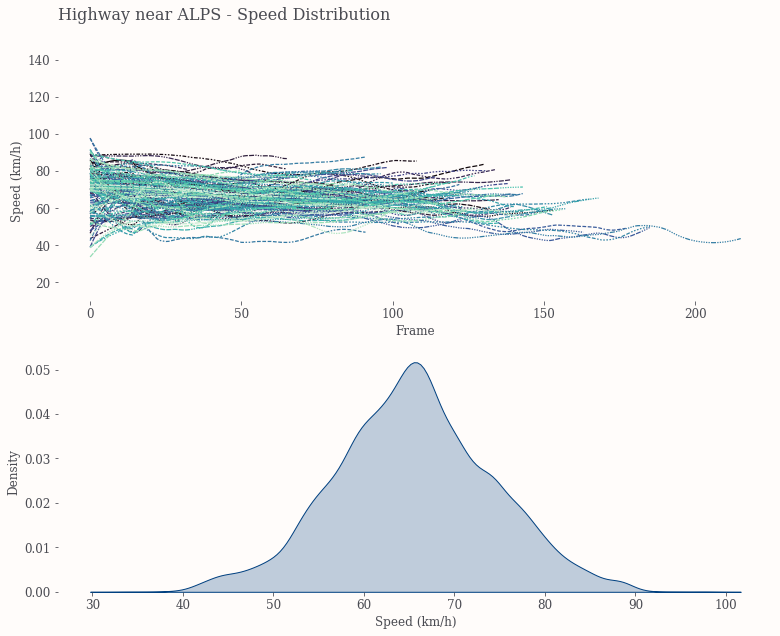

In [23]:
warnings.simplefilter("ignore")
speed_df = pd.DataFrame.from_dict(speedometer.speeds, orient="index").transpose()
speed_df = speed_df.clip(  # Remove extreme outliers and smooth the curve.
    lower=float(np.nanpercentile(speed_df, 1)),
    upper=float(np.nanpercentile(speed_df, 99)),
).apply(lambda x: savgol_filter(x, FPS, 2))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), tight_layout=True)
sns.lineplot(speed_df, palette="mako", linewidth=1.25, ax=ax1)
ax1.set_xlabel("Frame")
ax1.set_ylabel("Speed (km/h)")
ax1.get_legend().set_visible(False)
ax1.set_ylim(10, 140)
ax1.set_title(
    "Highway near ALPS - Speed Distribution",
    loc="left",
    pad=40,
)
sns.kdeplot(speed_df.to_numpy().ravel(), fill=True, color="#004080", linewidth=1, ax=ax2)
ax2.set_xlabel("Speed (km/h)")
ax2.set_ylabel("Density")
plt.show()